# Initial-shock variability: E3SM and CESM-SMYLE

Archive-backed companion to `1a_refactor_atm_leadtime_acc_skill_map.ipynb`.

**Configure → inventory and cache plan → monthly archive preparation and common-grid
calculation → cached diagnostics → case comparisons → individual initialization plots.**

This uses the same E3SM post-processing archive, CESM-SMYLE benchmark archive,
observation accessors and regridding utilities as `1a`. The calculation is separate:
no detrending, lead-drift removal, or ACC anomaly inputs. The primary diagnostics
compare matching three-month seasons across the two lead years; the legacy annual
standard-deviation ratio is retained for continuity.


In [104]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

repo_root = next((p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'esp_lab').is_dir()), None)
if repo_root is None:
    raise RuntimeError('Run this notebook from the repository root or jupyter directory')
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from importlib import reload
from esp_lab.diagnostics import initial_shock as initial_shock_diagnostic
from workflows.diagnostics import initial_shock_archive as initial_shock_archive_workflow
from esp_lab.utils.dask_util import DaskConfig, get_cluster_client
from esp_lab.utils.resource_utils import ResourceTracker

initial_shock_diagnostic = reload(initial_shock_diagnostic)
plot_std_ratio = initial_shock_diagnostic.plot_std_ratio
plot_normalized_change = initial_shock_diagnostic.plot_normalized_change

if initial_shock_archive_workflow.ARCHIVE_VERSION != 'initial_shock_archive_v4':
    initial_shock_archive_workflow = reload(initial_shock_archive_workflow)
plan_archive_run = initial_shock_archive_workflow.plan_archive_run
compute_archive_plan = initial_shock_archive_workflow.compute_archive_plan


## User setup and workflow configuration

Select a field and the E3SM cases here, as in `1a`. Input files are discovered through
the existing archive accessors; no manually prepared monthly filenames are needed.
`TREFHT` is the temperature diagnostic used in the NCL example. All conversion
factors below assume the same archive conventions as `1a`; PRECT is mm/day after conversion.

The primary comparison pairs each three-month season in lead year 1 with the same
season in lead year 2. This avoids confusing adjacent-season climatology with
forecast adjustment. The original NCL index needs five annual samples (60 months);
the legacy two-block annual ratio retained here is exploratory and is not the
original five-year statistic. Set `FORCE_COMPUTE=False` to reuse every compatible
processed metric and calculate only missing or stale products. Use `True` only when
you intentionally want to rebuild all requested case/month products.


In [105]:

VAR_CONFIG = {
    'TREFHT': dict(obs_product='ERA5', obs_variable='tas', units='degC',
                   model_scale=1., model_offset=-273.15, smyle_scale=1., smyle_offset=-273.15,
                   obs_scale=1., obs_offset=-273.15),
    'TS': dict(obs_product='ERA5', obs_variable='ts', units='degC',
               model_scale=1., model_offset=-273.15, smyle_scale=1., smyle_offset=-273.15,
               obs_scale=1., obs_offset=-273.15),
    'PRECT': dict(obs_product='GPCP_v2.3', obs_variable='PRECT', units='mm/day',
                  model_scale=86400000., model_offset=0., smyle_scale=86400000., smyle_offset=0.,
                  obs_scale=1., obs_offset=0.),
    'PSL': dict(obs_product='ERA5', obs_variable='psl', units='hPa',
                model_scale=.01, model_offset=0., smyle_scale=.01, smyle_offset=0.,
                obs_scale=.01, obs_offset=0.),
}

field = 'TS' #'PRECT' #'PSL' #'TS' #'TREFHT'
variable = dict(VAR_CONFIG[field], field=field, model_variable=field, smyle_variable=field)

# Optional common processing end year. None uses the full period.
YEAR_END = 2011  # None

# False: reuse compatible processed metrics and compute only missing/stale products.
# True: ignore compatible metric caches and recompute every requested case/month.
FORCE_COMPUTE = False

clim1=1981
clim2=2010
init_months = [5, 11]
nlead = 24

target_dlat = 5.0
target_dlon = 5.0
regrid_method = 'conservative'
periodic = True

E3SM_CASES = {
    'E3SM-FOSIRL': dict(case_prefix='WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL', cache_tag='JRA55_FOSIRL'),
    'E3SM-Reanalysis': dict(case_prefix='WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_BruteForce', cache_tag='Reanalysis'),
    'E3SM-4DEnVarOcn': dict(case_prefix='WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_4DEnVarOcn', cache_tag='4DEnVarOcn'),
}

WORKFLOW_SETTINGS = {
    'paths': {
        's2d_diag_root': '/global/cfs/cdirs/e3sm/S2S2D/s2d_diag',
        'figure_outdir': '/global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/initial_shock',
    },
    'run': {
        'years': [1980, 2018 if YEAR_END is None else int(YEAR_END)],
        'init_months': init_months, 
        'nlead': nlead, 
        'smoke_mode': False
    },
    'e3sm': {
        'data_dir': '/global/cfs/cdirs/e3sm/S2S2D/post_process',
        'nens': 10, 'grid': '180x360_aave', 'ts_split': '2yr', 'engine': 'netcdf4',
        'chunks': {'Y': 3, 'L': 24, 'M': 2, 'lat': 90, 'lon': 180},
    },
    'smyle': {
        'include': True, 'nens': 20,
        'benchmark_dir': '/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/CESM-SMYLE',
        'chunks': {'Y': 3, 'L': 24, 'M': 2, 'lat': 96, 'lon': 144},
    },
    'obs': {
        'data_dir': '/global/cfs/cdirs/e3sm/e3sm_diags/obs_for_e3sm_diags/time-series',
        'chunks': {'time': 24, 'lat': 90, 'lon': 180},
    },
    'regrid': {
        'target_dlat': target_dlat, 
        'target_dlon': target_dlon, 
        'method': regrid_method, 
        'periodic': periodic
    },
    'metric': {
        'window_months': 24, 
        'block_months': 12, 
        'start_lead': 0,
        'min_samples': None, 
        'min_area_fraction': .9,
        'climatology_years': [clim1, clim2]
    },
    'cache': {
        'mode': 'auto', 
        'force_compute': FORCE_COMPUTE
    },
    'dask': {
        'enabled': True, 
        'cluster_type': 'local',
        'workers': 4,
        'memory_limit': '4GB'
    },
}

if WORKFLOW_SETTINGS['run']['smoke_mode']:
    E3SM_CASES = {'E3SM-FOSIRL': E3SM_CASES['E3SM-FOSIRL']}
    WORKFLOW_SETTINGS['run'].update(years=[1980, 1981], init_months=[11])
    WORKFLOW_SETTINGS['regrid'].update(target_dlat=5., target_dlon=5.)
    WORKFLOW_SETTINGS['dask']['workers'] = 2
    print('Archive-backed smoke mode: one E3SM case, CESM-SMYLE, two starts, one month.')
    
print('Field:', field, '| Years:', WORKFLOW_SETTINGS['run']['years'])
print('Metric:', WORKFLOW_SETTINGS['metric'])
print('Cache policy:', 'force recompute' if FORCE_COMPUTE else 'reuse valid, compute missing')


Field: TS | Years: [1980, 2011]
Metric: {'window_months': 24, 'block_months': 12, 'start_lead': 0, 'min_samples': None, 'min_area_fraction': 0.9, 'climatology_years': [1981, 2010]}
Cache policy: reuse valid, compute missing


## Inventory and cache plan

Inventory all requested initializations before starting expensive processing.
All E3SM members are required. Missing initializations cause an error rather than
silently shortening a case's comparison period. This also checks CESM-SMYLE
**monthly** benchmark availability and identifies the observation source.

Identity includes source file inventories, settings and adapter code. Compatible
metric caches can be reused without remapping the data. `require` needs source
metadata and existing compatible caches. Rerun this cell after changing settings.


In [ ]:
archive_plan = plan_archive_run(WORKFLOW_SETTINGS, E3SM_CASES, variable)
plan_table = pd.DataFrame([
    {'case': t['case'], 'init_month': t['month'], 'initializations': len(t['years']),
     'source_files': len(t['inventory']), 'action': 'prepare' if t['rebuild'] else 'reuse',
     'cache': t['path']}
    for t in archive_plan
])
display(plan_table)


## Dask resources

Start after the inventory succeeds. A local cluster starts only when the plan contains
work to rebuild; rerunning this cell closes any previous cluster. The computation cell
always releases Dask resources, including when computation raises an exception.


In [ ]:
from esp_lab.utils.notebook_resources import restart_notebook_cluster, close_notebook_resources

needs_distributed_compute = (
    WORKFLOW_SETTINGS['dask']['enabled']
    and any(task['rebuild'] for task in archive_plan)
)
cluster, client, workflow_resources = restart_notebook_cluster(
    globals(),
    lambda: get_cluster_client(DaskConfig(
        cluster_type=WORKFLOW_SETTINGS['dask']['cluster_type'],
        workers=WORKFLOW_SETTINGS['dask']['workers'],
        memory_limit=WORKFLOW_SETTINGS['dask']['memory_limit'],
    )) if needs_distributed_compute else (None, None),
)
if client is not None:
    display(client)
elif WORKFLOW_SETTINGS['dask']['enabled']:
    print('All exact-period caches are valid; skipped distributed cluster startup.')


Dask scheduler: local threads
All exact-period caches are valid; skipped distributed cluster startup.


## Monthly preparation, common-grid calculation, and cache writing

For each missing case/month product, the module opens monthly archives, validates
represented verification months, converts units, regrids model and observation,
and computes the metric. Each source dataset is closed after the calculation.

To save space, the preparation and metric stages write **compact global seasonal and
annual indices, coverage and normalized changes**, not duplicate gridded monthly files. These live
under `<case>/initial_shock/metrics/atm/<field>/`, separate from ACC/RMSE outputs.
Seasonal changes use matching seasons twelve months apart and a season-specific
observed interannual standard deviation over `metric.climatology_years`.


In [ ]:
try:
    comparison_by_month = compute_archive_plan(archive_plan, WORKFLOW_SETTINGS, variable)
finally:
    close_notebook_resources(globals())
    print('Closed Dask resources after computation.')
for month, comparison in comparison_by_month.items():
    print(f'Initialization month {month:02d}')
    display(comparison[['seasonal_signed_normalized_change',
                        'seasonal_absolute_normalized_change',
                        'seasonal_excess_normalized_change',
                        'seasonal_observation_climatology_std',
                        'std_ratio', 'paired_sample_count', 'valid_normalized_change']])


Reusing E3SM-FOSIRL init 05: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/JRA55_FOSIRL/initial_shock/metrics/atm/TREFHT/init05_1980_2011.nc
Reusing E3SM-Reanalysis init 05: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/Reanalysis/initial_shock/metrics/atm/TREFHT/init05_1980_2011.nc
Reusing E3SM-4DEnVarOcn init 05: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/4DEnVarOcn/initial_shock/metrics/atm/TREFHT/init05_1980_2011.nc
Reusing CESM-SMYLE init 05: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/CESM-SMYLE/initial_shock/metrics/atm/TREFHT/init05_1980_2011.nc
Reusing E3SM-FOSIRL init 11: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/JRA55_FOSIRL/initial_shock/metrics/atm/TREFHT/init11_1980_2011.nc
Reusing E3SM-Reanalysis init 11: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/Reanalysis/initial_shock/metrics/atm/TREFHT/init11_1980_2011.nc
Reusing E3SM-4DEnVarOcn init 11: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/4DEnVarOcn/initial_shock/metrics/atm/TREFHT/init11_1980_2011.nc
Reusing CESM-SMYLE init 11: /global/cfs/cdirs/e3sm/S2S2D/s2d_dia

<xarray.Dataset> Size: 15kB
Dimensions:                               (case: 4, Y: 32, season: 4)
Coordinates:
  * case                                  (case) object 32B 'E3SM-FOSIRL' ......
  * Y                                     (Y) int64 256B 1980 1981 ... 2010 2011
  * season                                (season) int64 32B 1 2 3 4
    season_label                          (season) <U7 112B 'May-Jul' ... 'Fe...
    height                                float64 8B 2.0
Data variables:
    seasonal_signed_normalized_change     (case, Y, season) float64 4kB -1.81...
    seasonal_absolute_normalized_change   (case, Y, season) float64 4kB 1.818...
    seasonal_excess_normalized_change     (case, Y, season) float64 4kB -1.48...
    seasonal_observation_climatology_std  (case, season) float64 128B 0.1712 ...
    std_ratio                             (case, Y) float64 1kB 2.461 ... 0.6352
    paired_sample_count                   (case, Y) int64 1kB 2 2 2 2 ... 2 2 2
    valid_normalized_change               (case, Y) int8 128B 1 1 1 1 ... 1 1 1
Attributes: (12/19)
    diagnostic_version:                     initial_shock_std_v4
    block_months:                           12
    window_months:                          24
    start_lead_position:                    0
    min_samples:                            2
    ddof:                                   1
    ...                                     ...
    seasonal_change_definition:             matching three-month season in le...
    seasonal_change_denominator:            season-specific sample std of obs...
    monthly_anomaly_climatology:            shared reference observation by c...
    monthly_standardized_error_definition:  (model monthly mean - observed mo...
    field:                                  TREFHT
    init_month:                             5

Initialization month 11


<xarray.Dataset> Size: 15kB
Dimensions:                               (case: 4, Y: 32, season: 4)
Coordinates:
  * case                                  (case) object 32B 'E3SM-FOSIRL' ......
  * Y                                     (Y) int64 256B 1980 1981 ... 2010 2011
  * season                                (season) int64 32B 1 2 3 4
    season_label                          (season) <U7 112B 'Nov-Jan' ... 'Au...
    height                                float64 8B 2.0
Data variables:
    seasonal_signed_normalized_change     (case, Y, season) float64 4kB -0.94...
    seasonal_absolute_normalized_change   (case, Y, season) float64 4kB 0.943...
    seasonal_excess_normalized_change     (case, Y, season) float64 4kB -0.69...
    seasonal_observation_climatology_std  (case, season) float64 128B 0.2156 ...
    std_ratio                             (case, Y) float64 1kB 1.254 ... 0.5236
    paired_sample_count                   (case, Y) int64 1kB 2 2 2 2 ... 2 2 2
    valid_normalized_change               (case, Y) int8 128B 1 1 1 1 ... 1 1 1
Attributes: (12/19)
    diagnostic_version:                     initial_shock_std_v4
    block_months:                           12
    window_months:                          24
    start_lead_position:                    0
    min_samples:                            2
    ddof:                                   1
    ...                                     ...
    seasonal_change_definition:             matching three-month season in le...
    seasonal_change_denominator:            season-specific sample std of obs...
    monthly_anomaly_climatology:            shared reference observation by c...
    monthly_standardized_error_definition:  (model monthly mean - observed mo...
    field:                                  TREFHT
    init_month:                             11

## Coverage, seasonal normalized-change tables and heatmap

For each season, the heatmap shows `|M_year2,s-M_year1,s| / sigma_obs,s`.
The four columns compare matching three-month seasons twelve months apart, never
adjacent seasons. May and November share one color scale. Annual diagnostics remain
in a separate CSV for continuity.


,case,Y,signed_normalized_change,absolute_normalized_change,excess_normalized_change,model_lead_year_change,observation_lead_year_change,observation_climatology_std,observation_climatology_sample_count,std_ratio,paired_sample_count,valid_normalized_change,height
0,E3SM-FOSIRL,1980,-1.415030,1.415030,-0.839942,-0.256781,-0.104359,0.181467,30,2.460547,2,1,2.0
1,E3SM-FOSIRL,1981,-1.447010,1.447010,-1.663802,-0.262585,0.039341,0.181467,30,6.674635,2,1,2.0
2,E3SM-FOSIRL,1982,-1.118267,1.118267,-1.078048,-0.202929,-0.007298,0.181467,30,27.804418,2,1,2.0
3,E3SM-FOSIRL,1983,-2.034041,2.034041,-1.182735,-0.369112,-0.154484,0.181467,30,2.389318,2,1,2.0
4,E3SM-FOSIRL,1984,-0.985449,0.985449,-1.179119,-0.178827,0.035145,0.181467,30,5.088308,2,1,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,CESM-SMYLE,2007,0.234801,0.234801,0.053006,0.042609,0.032990,0.181467,30,1.291568,2,1,2.0
124,CESM-SMYLE,2008,0.565098,0.565098,-0.381431,0.102547,0.171764,0.181467,30,0.597021,2,1,2.0
125,CESM-SMYLE,2009,0.605801,0.605801,1.152614,0.109933,-0.099229,0.181467,30,1.107874,2,1,2.0
126,CESM-SMYLE,2010,-0.167864,0.167864,0.095255,-0.030462,-0.047747,0.181467,30,0.637978,2,1,2.0


<xarray.Dataset> Size: 2kB
Dimensions:                    (case: 4, Y: 32)
Coordinates:
  * case                       (case) object 32B 'E3SM-FOSIRL' ... 'CESM-SMYLE'
  * Y                          (Y) int64 256B 1980 1981 1982 ... 2009 2010 2011
    height                     float64 8B 2.0
Data variables:
    model_area_fraction        (case, Y) float64 1kB 1.0 1.0 1.0 ... 1.0 1.0 1.0
    observation_area_fraction  (case, Y) float64 1kB 1.0 1.0 1.0 ... 1.0 1.0 1.0
Attributes: (12/19)
    diagnostic_version:                     initial_shock_std_v4
    block_months:                           12
    window_months:                          24
    start_lead_position:                    0
    min_samples:                            2
    ddof:                                   1
    ...                                     ...
    seasonal_change_definition:             matching three-month season in le...
    seasonal_change_denominator:            season-specific sample std of obs...
    monthly_anomaly_climatology:            shared reference observation by c...
    monthly_standardized_error_definition:  (model monthly mean - observed mo...
    field:                                  TREFHT
    init_month:                             5

,case,Y,season,seasonal_signed_normalized_change,seasonal_absolute_normalized_change,seasonal_excess_normalized_change,seasonal_model_year_change,seasonal_observation_year_change,seasonal_observation_climatology_std,seasonal_observation_climatology_sample_count,valid_seasonal_normalized_change,height,season_label
0,E3SM-FOSIRL,1980,1,-1.817967,1.817967,-1.487568,-0.311291,-0.056574,0.171231,30,1,2.0,May-Jul
1,E3SM-FOSIRL,1980,2,-1.330947,1.330947,-1.519442,-0.271459,0.038445,0.203959,30,1,2.0,Aug-Oct
2,E3SM-FOSIRL,1980,3,-1.220977,1.220977,-0.967883,-0.263234,-0.054565,0.215593,30,1,2.0,Nov-Jan
3,E3SM-FOSIRL,1980,4,-0.910738,0.910738,0.822551,-0.181142,-0.344743,0.198895,30,1,2.0,Feb-Apr
4,E3SM-FOSIRL,1981,1,-1.658351,1.658351,-0.865712,-0.283960,-0.135724,0.171231,30,1,2.0,May-Jul
...,...,...,...,...,...,...,...,...,...,...,...,...,...
507,CESM-SMYLE,2010,4,0.503800,0.503800,0.573923,0.100204,-0.013947,0.198895,30,1,2.0,Feb-Apr
508,CESM-SMYLE,2011,1,0.339728,0.339728,-0.069372,0.058172,0.070050,0.171231,30,1,2.0,May-Jul
509,CESM-SMYLE,2011,2,0.496755,0.496755,0.131168,0.101318,0.074565,0.203959,30,1,2.0,Aug-Oct
510,CESM-SMYLE,2011,3,0.197503,0.197503,-0.744298,0.042580,0.203046,0.215593,30,1,2.0,Nov-Jan


,case,Y,signed_normalized_change,absolute_normalized_change,excess_normalized_change,model_lead_year_change,observation_lead_year_change,observation_climatology_std,observation_climatology_sample_count,std_ratio,paired_sample_count,valid_normalized_change,height
0,E3SM-FOSIRL,1980,-1.135447,1.135447,-0.230324,-0.214940,-0.171340,0.1893,30,1.254467,2,1,2.0
1,E3SM-FOSIRL,1981,-0.950129,0.950129,-1.948539,-0.179860,0.188999,0.1893,30,0.951642,2,1,2.0
2,E3SM-FOSIRL,1982,-1.718333,1.718333,-0.798320,-0.325281,-0.174159,0.1893,30,1.867727,2,1,2.0
3,E3SM-FOSIRL,1983,-1.222326,1.222326,-0.742907,-0.231387,-0.090754,0.1893,30,2.549599,2,1,2.0
4,E3SM-FOSIRL,1984,-0.702574,0.702574,-1.144685,-0.132998,0.083692,0.1893,30,1.589138,2,1,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,CESM-SMYLE,2007,-0.225918,0.225918,-0.883898,-0.042766,0.124556,0.1893,30,0.343352,2,1,2.0
124,CESM-SMYLE,2008,-0.110516,0.110516,-0.786943,-0.020921,0.128048,0.1893,30,0.163382,2,1,2.0
125,CESM-SMYLE,2009,-0.815848,0.815848,-0.062515,-0.154440,-0.142606,0.1893,30,1.082985,2,1,2.0
126,CESM-SMYLE,2010,-0.167060,0.167060,-0.231105,-0.031624,0.012124,0.1893,30,2.608479,2,1,2.0


<xarray.Dataset> Size: 2kB
Dimensions:                    (case: 4, Y: 32)
Coordinates:
  * case                       (case) object 32B 'E3SM-FOSIRL' ... 'CESM-SMYLE'
  * Y                          (Y) int64 256B 1980 1981 1982 ... 2009 2010 2011
    height                     float64 8B 2.0
Data variables:
    model_area_fraction        (case, Y) float64 1kB 1.0 1.0 1.0 ... 1.0 1.0 1.0
    observation_area_fraction  (case, Y) float64 1kB 1.0 1.0 1.0 ... 1.0 1.0 1.0
Attributes: (12/19)
    diagnostic_version:                     initial_shock_std_v4
    block_months:                           12
    window_months:                          24
    start_lead_position:                    0
    min_samples:                            2
    ddof:                                   1
    ...                                     ...
    seasonal_change_definition:             matching three-month season in le...
    seasonal_change_denominator:            season-specific sample std of obs...
    monthly_anomaly_climatology:            shared reference observation by c...
    monthly_standardized_error_definition:  (model monthly mean - observed mo...
    field:                                  TREFHT
    init_month:                             11

,case,Y,season,seasonal_signed_normalized_change,seasonal_absolute_normalized_change,seasonal_excess_normalized_change,seasonal_model_year_change,seasonal_observation_year_change,seasonal_observation_climatology_std,seasonal_observation_climatology_sample_count,valid_seasonal_normalized_change,height,season_label
0,E3SM-FOSIRL,1980,1,-0.943720,0.943720,-0.690625,-0.203459,-0.054565,0.215593,30,1,2.0,Nov-Jan
1,E3SM-FOSIRL,1980,2,-1.065579,1.065579,0.667711,-0.211939,-0.344743,0.198895,30,1,2.0,Feb-Apr
2,E3SM-FOSIRL,1980,3,-1.176599,1.176599,-0.399945,-0.205616,-0.135724,0.174755,30,1,2.0,May-Jul
3,E3SM-FOSIRL,1980,4,-1.147129,1.147129,-0.424838,-0.238747,-0.150328,0.208126,30,1,2.0,Aug-Oct
4,E3SM-FOSIRL,1981,1,-0.442839,0.442839,-0.950460,-0.095473,0.109439,0.215593,30,1,2.0,Nov-Jan
...,...,...,...,...,...,...,...,...,...,...,...,...,...
507,CESM-SMYLE,2010,4,0.874898,0.874898,0.516631,0.182089,0.074565,0.208126,30,1,2.0,Aug-Oct
508,CESM-SMYLE,2011,1,-0.327376,0.327376,-1.269178,-0.070580,0.203046,0.215593,30,1,2.0,Nov-Jan
509,CESM-SMYLE,2011,2,-0.426725,0.426725,-0.875165,-0.084874,0.089193,0.198895,30,1,2.0,Feb-Apr
510,CESM-SMYLE,2011,3,0.349126,0.349126,0.788630,0.061011,-0.076806,0.174755,30,1,2.0,May-Jul


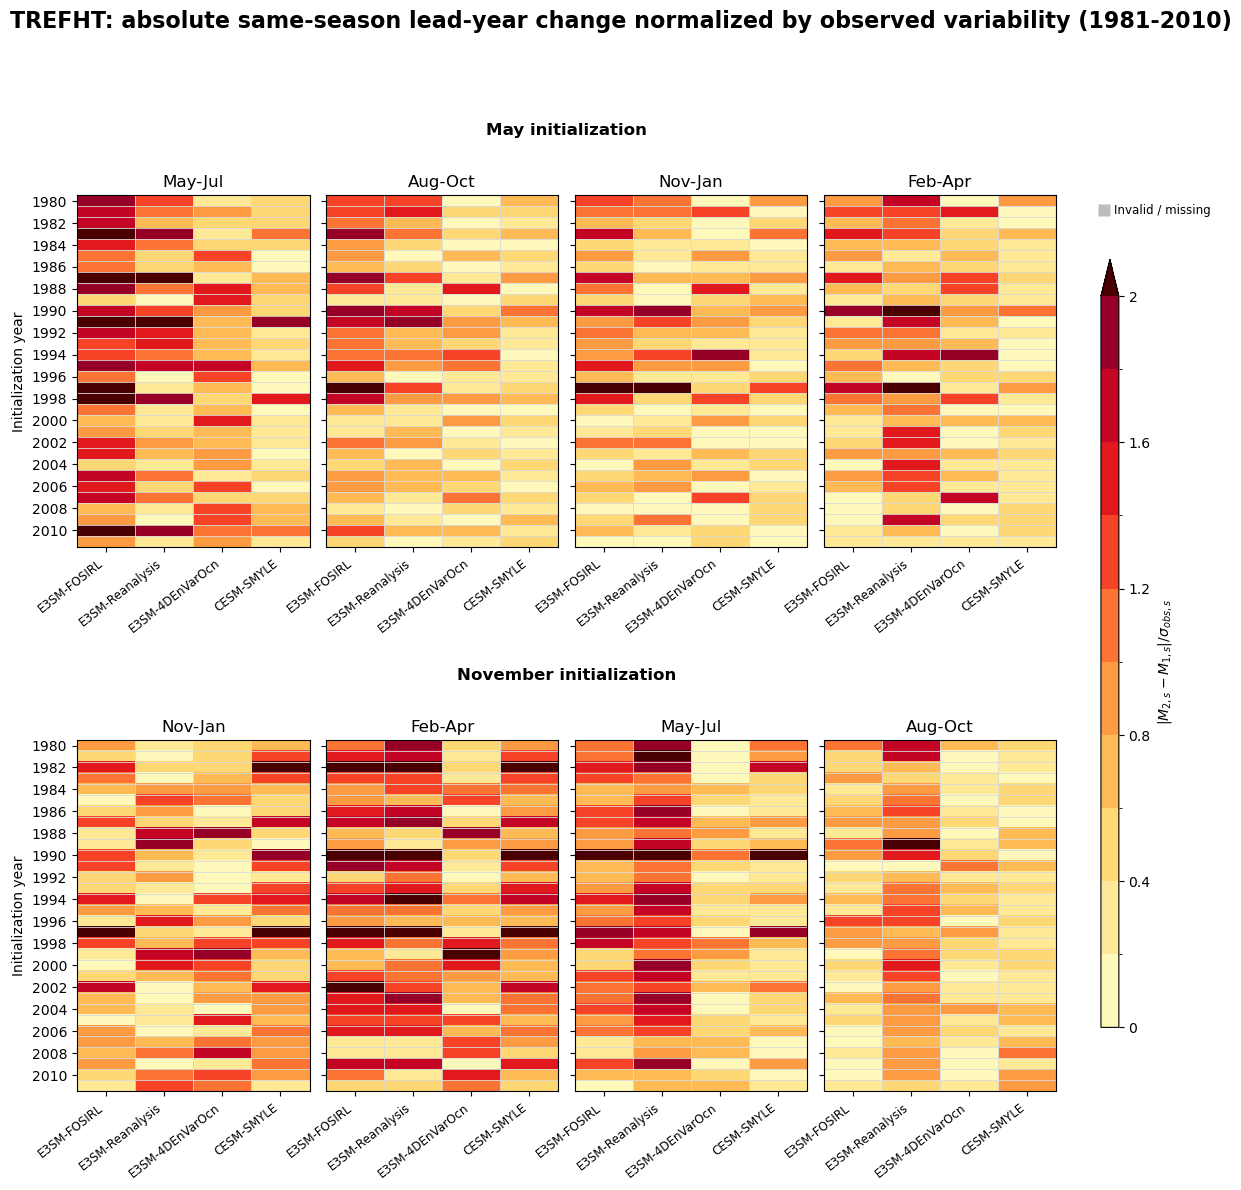

Saved seasonal absolute normalized-change comparison: /global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/initial_shock/TREFHT_init05-init11_1980_2011_seasonal_absolute_normalized_change.png


In [ ]:
FIGURE_ROOT = Path(WORKFLOW_SETTINGS['paths']['figure_outdir'])
FIGURE_ROOT.mkdir(parents=True, exist_ok=True)

period_start, period_end = WORKFLOW_SETTINGS['run']['years']
period_token = f'{period_start}_{period_end}'

for month, comparison in comparison_by_month.items():
    prefix = f'{field}_init{month:02d}_{period_token}'
    summary = comparison[['signed_normalized_change', 'absolute_normalized_change',
                          'excess_normalized_change', 'model_lead_year_change',
                          'observation_lead_year_change', 'observation_climatology_std',
                          'observation_climatology_sample_count', 'std_ratio',
                          'paired_sample_count', 'valid_normalized_change']].to_dataframe().reset_index()
    display(summary)
    display(comparison[['model_area_fraction', 'observation_area_fraction']].min('block'))
    summary.to_csv(FIGURE_ROOT / f'{prefix}_summary.csv', index=False)
    seasonal_summary = comparison[[
        'seasonal_signed_normalized_change', 'seasonal_absolute_normalized_change',
        'seasonal_excess_normalized_change', 'seasonal_model_year_change',
        'seasonal_observation_year_change', 'seasonal_observation_climatology_std',
        'seasonal_observation_climatology_sample_count',
        'valid_seasonal_normalized_change',
    ]].to_dataframe().reset_index()
    display(seasonal_summary)
    seasonal_summary.to_csv(FIGURE_ROOT / f'{prefix}_seasonal_summary.csv', index=False)

plot_months = list(comparison_by_month)
max_years = max(comparison_by_month[month].sizes['Y'] for month in plot_months)
month_names = {5: 'May', 11: 'November'}
month_token = '-'.join(f'init{month:02d}' for month in plot_months)
season_values = list(map(int, comparison_by_month[plot_months[0]].season.values))
fig, axes = plt.subplots(
    len(plot_months), len(season_values),
    figsize=(3.2 * len(season_values), max(10, max_years * .40)),
    sharey='row', squeeze=False,
)
for row, month in enumerate(plot_months):
    comparison = comparison_by_month[month]
    year_positions = np.arange(comparison.sizes['Y'])
    year_labels = np.asarray(comparison.Y).astype(str)
    for col, season in enumerate(season_values):
        ax = axes[row, col]
        season_label = str(comparison.season_label.sel(season=season).item())
        plot_normalized_change(
            comparison.sel(season=season),
            variable='seasonal_absolute_normalized_change',
            levels=np.linspace(0.0, 2.0, 11), ax=ax,
            add_colorbar=False, add_invalid_legend=False,
            title=season_label,
        )
        ax.set_yticks(year_positions[::2], labels=year_labels[::2])
        ax.tick_params(axis='x', labelsize=8.5)
        plt.setp(ax.get_xticklabels(), rotation=38, ha='right')
        if col:
            ax.set_ylabel('')
            ax.tick_params(labelleft=False)
        else:
            ax.set_ylabel('Initialization year')

mesh = axes[0, 0].images[0]
bounds = np.asarray(mesh.norm.boundaries)
fig.subplots_adjust(left=.075, right=.84, bottom=.14, top=.84, wspace=.07, hspace=.55)
for row, month in enumerate(plot_months):
    left = axes[row, 0].get_position().x0
    right = axes[row, -1].get_position().x1
    fig.text(
        (left + right) / 2, axes[row, 0].get_position().y1 + .045,
        f"{month_names.get(month, f'Month {month:02d}')} initialization",
        ha='center', va='bottom', fontsize=12, fontweight='semibold',
    )
colorbar_ax = fig.add_axes([.875, .19, .014, .60])
colorbar = fig.colorbar(
    mesh, cax=colorbar_ax, ticks=bounds[::2], extend='max',
)
colorbar.set_label(r'$|M_{2,s}-M_{1,s}| / \sigma_{obs,s}$')
colorbar.ax.set_yticklabels([f'{value:g}' for value in bounds[::2]])
invalid_handle = plt.Line2D(
    [], [], marker='s', linestyle='none', markersize=8,
    markerfacecolor=mesh.cmap.get_bad(), markeredgecolor='none',
    label='Invalid / missing',
)
fig.legend(
    handles=[invalid_handle], loc='lower left', bbox_to_anchor=(.865, .815),
    frameon=False, fontsize=8.5, handlelength=.9, handletextpad=.4,
)
climatology_label = comparison_by_month[plot_months[0]].attrs.get(
    'normalized_change_climatology', 'available years'
)
fig.suptitle(
    f'{field}: absolute same-season lead-year change normalized by observed variability '
    f'({climatology_label})', fontsize=16, fontweight='bold', y=.985,
)
figure_path = (
    FIGURE_ROOT
    / f'{field}_{month_token}_{period_token}_seasonal_absolute_normalized_change.png'
)
fig.savefig(figure_path, dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)
print('Saved seasonal absolute normalized-change comparison:', figure_path)


## Compare seasonal model and observed lead-year changes

Each point is an initialization year for one matching season in lead years 1 and 2.
The 1:1 line denotes equal model and observed same-season change; displacement from
it is the seasonal excess normalized-change diagnostic.


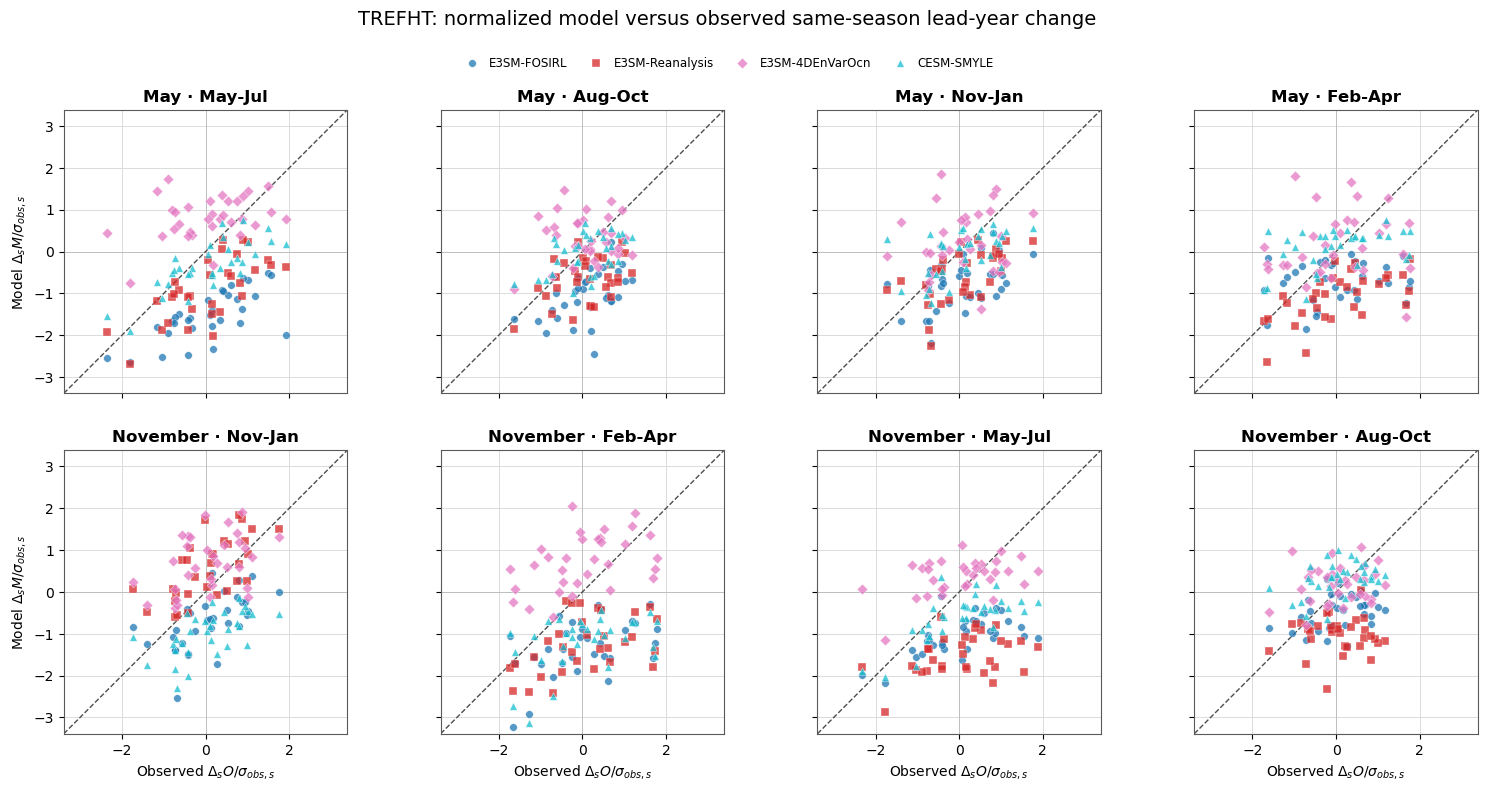

Saved seasonal normalized-change scatter: /global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/initial_shock/TREFHT_init05-init11_1980_2011_seasonal_normalized_change_scatter.png


In [ ]:
plot_months = list(comparison_by_month)
case_names = list(dict.fromkeys(
    str(case) for month in plot_months for case in comparison_by_month[month].case.values
))
case_colors = dict(zip(
    case_names, plt.colormaps['tab10'](np.linspace(0, 1, max(2, len(case_names))))
))
default_case_markers = {
    'E3SM-FOSIRL': 'o',
    'E3SM-Reanalysis': 's',
    'E3SM-4DEnVarOcn': 'D',
    'CESM-SMYLE': '^',
    'NMME': 'X',
}
fallback_markers = ('o', 's', 'D', '^', 'v', 'P', 'X', '*')
case_markers = {
    case: default_case_markers.get(case, fallback_markers[index % len(fallback_markers)])
    for index, case in enumerate(case_names)
}
finite_changes = []
for comparison in comparison_by_month.values():
    observed_normalized = (
        comparison.seasonal_observation_year_change
        / comparison.seasonal_observation_climatology_std
    )
    for values in (
        observed_normalized.values, comparison.seasonal_signed_normalized_change.values,
    ):
        values = np.asarray(values, dtype=float)
        finite_changes.extend(values[np.isfinite(values)].tolist())
if not finite_changes:
    raise ValueError('No finite seasonal normalized lead-year changes to plot.')
axis_limit = max(1.0, max(abs(value) for value in finite_changes) * 1.05)

season_values = list(map(int, comparison_by_month[plot_months[0]].season.values))
fig, axes = plt.subplots(
    len(plot_months), len(season_values),
    figsize=(4.0 * len(season_values), 4.0 * len(plot_months)),
    sharex=True, sharey=True, squeeze=False,
)
month_names = {5: 'May', 11: 'November'}
for row, month in enumerate(plot_months):
    comparison = comparison_by_month[month]
    for col, season in enumerate(season_values):
        ax = axes[row, col]
        season_label = str(comparison.season_label.sel(season=season).item())
        for case in case_names:
            if case not in set(map(str, comparison.case.values)):
                continue
            data = comparison.sel(case=case, season=season)
            observed = np.asarray(
                (data.seasonal_observation_year_change
                 / data.seasonal_observation_climatology_std).values,
                dtype=float,
            )
            modeled = np.asarray(
                data.seasonal_signed_normalized_change.values, dtype=float,
            )
            valid = np.isfinite(observed) & np.isfinite(modeled)
            ax.scatter(
                observed[valid], modeled[valid], s=30, alpha=.75,
                marker=case_markers[case], color=case_colors[case],
                edgecolor='white', linewidth=.35, label=case, zorder=3,
            )
        ax.plot(
            [-axis_limit, axis_limit], [-axis_limit, axis_limit],
            color='.30', linestyle='--', linewidth=1.0, zorder=2,
        )
        ax.axhline(0, color='.75', linewidth=.7, zorder=1)
        ax.axvline(0, color='.75', linewidth=.7, zorder=1)
        ax.set(
            xlim=(-axis_limit, axis_limit), ylim=(-axis_limit, axis_limit),
            title=f"{month_names.get(month, f'Month {month:02d}')} · {season_label}",
        )
        if row == len(plot_months) - 1:
            ax.set_xlabel(r'Observed $\Delta_s O / \sigma_{obs,s}$')
        if col == 0:
            ax.set_ylabel(r'Model $\Delta_s M / \sigma_{obs,s}$')
        ax.title.set_fontweight('semibold')
        ax.set_aspect('equal', adjustable='box')
        ax.set_axisbelow(True)
        ax.grid(color='.86', linewidth=.7)
        for spine in ax.spines.values():
            spine.set_color('.35')
            spine.set_linewidth(.8)
fig.suptitle(
    f'{field}: normalized model versus observed same-season lead-year change',
    y=.985, fontsize=14,
)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles, labels, loc='upper center', bbox_to_anchor=(.5, .94),
    ncol=max(1, len(case_names)), fontsize=8.5, frameon=False,
    handletextpad=.5, columnspacing=1.4,
)
fig.subplots_adjust(left=.07, right=.985, bottom=.08, top=.86, wspace=.13, hspace=.20)

month_token = '-'.join(f'init{month:02d}' for month in plot_months)
scatter_path = FIGURE_ROOT / f'{field}_{month_token}_{period_token}_seasonal_normalized_change_scatter.png'
fig.savefig(scatter_path, dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)
print('Saved seasonal normalized-change scatter:', scatter_path)


## Evolution of monthly standardized anomalies

Model and reference anomalies use the same observed calendar-month climatology:
`(X-mu_obs,month) / sigma_obs,month`. This removes the observed seasonal cycle.
Each initialization month gets a separate figure, with model cases down the rows,
the first ensemble member at left, and the ensemble mean at right. Colored 24-month
segments are initialized forecasts; the continuous black curve is the observation.


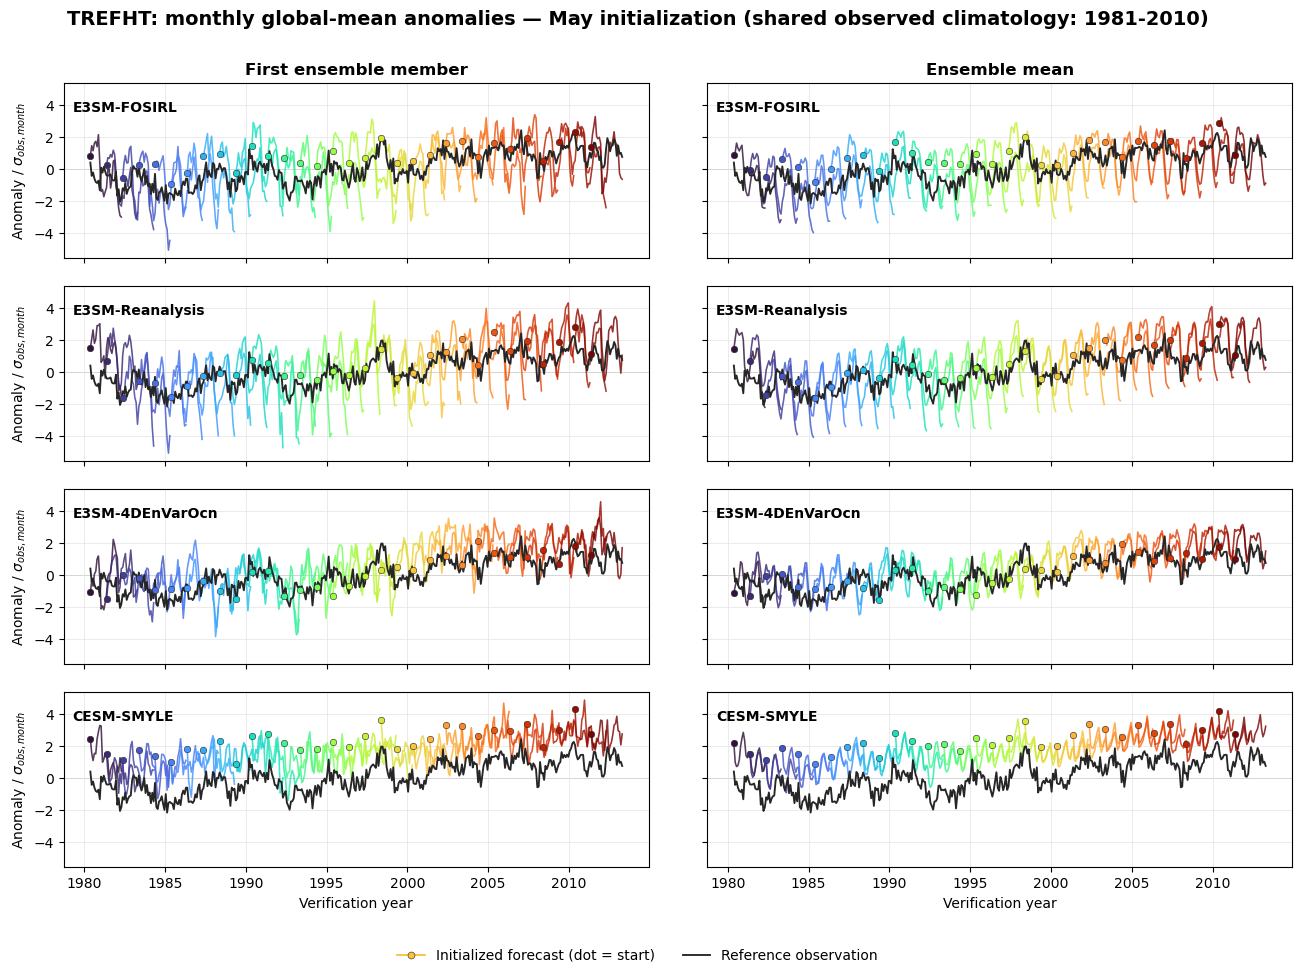

Saved monthly member-versus-mean anomaly evolution: /global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/initial_shock/TREFHT_init05_1980_2011_monthly_anomaly_member_vs_mean.png


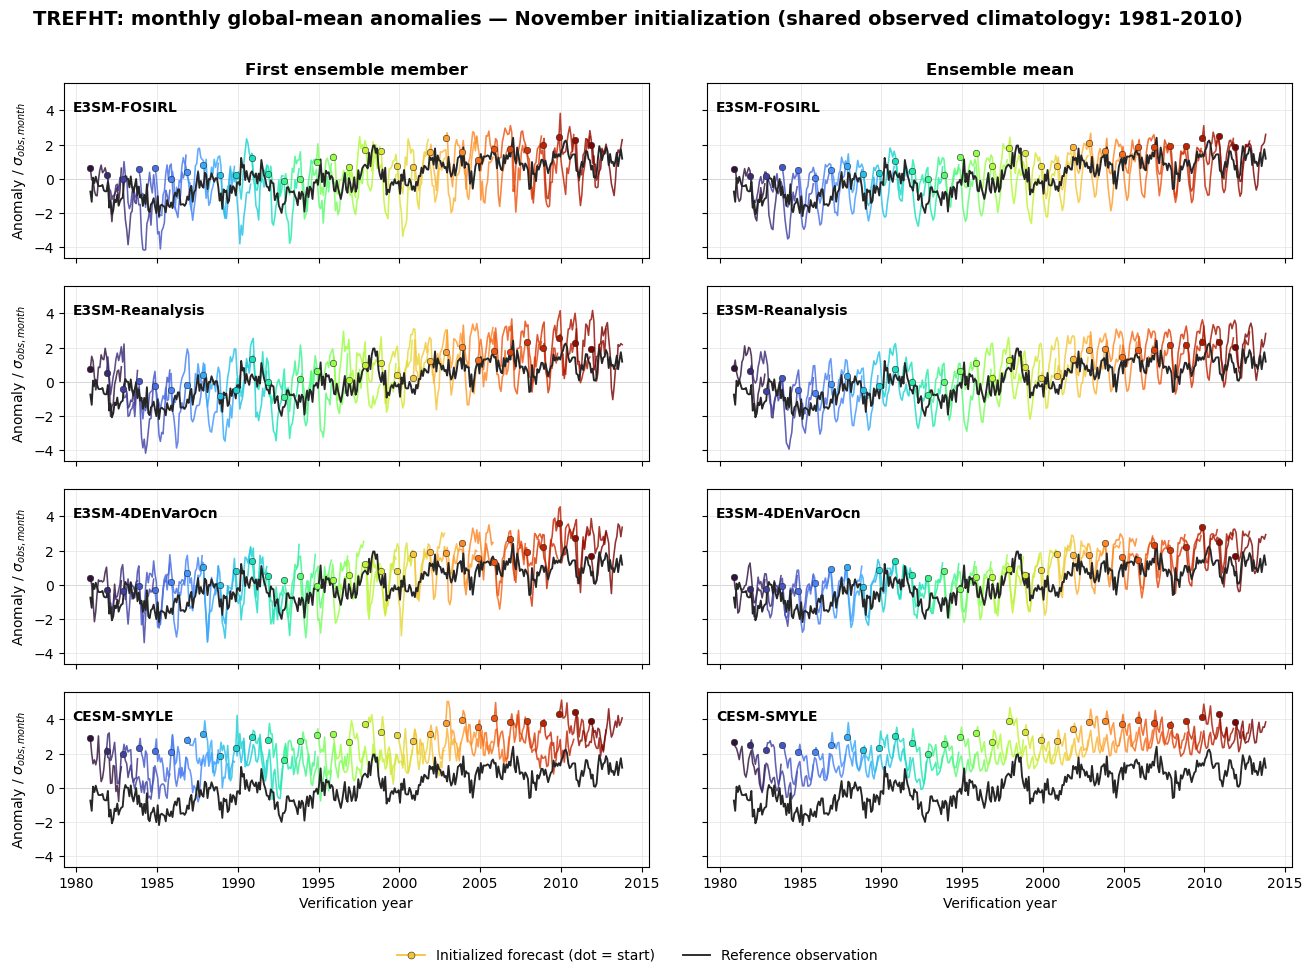

Saved monthly member-versus-mean anomaly evolution: /global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/initial_shock/TREFHT_init11_1980_2011_monthly_anomaly_member_vs_mean.png


In [ ]:
from matplotlib.colors import Normalize

evolution_months = list(comparison_by_month)
evolution_cases = list(dict.fromkeys(
    str(case) for month in evolution_months
    for case in comparison_by_month[month].case.values
))
if not evolution_months or not evolution_cases:
    raise ValueError('No monthly indices are available for the evolution figure.')
for month, comparison in comparison_by_month.items():
    required_monthly = {
        'monthly_verification_time', 'monthly_first_member_normalized_anomaly',
        'monthly_model_normalized_anomaly', 'monthly_observation_normalized_anomaly',
    }
    missing = required_monthly - set(comparison.variables)
    if missing:
        raise RuntimeError(
            f'Initialization month {month:02d} uses an obsolete cache missing '
            f'{sorted(missing)}. Rerun inventory and computation cells.'
        )
month_names = {5: 'May', 11: 'November'}
monthly_climatology_years = WORKFLOW_SETTINGS['metric'].get('climatology_years')
monthly_climatology_label = (
    'all available years' if monthly_climatology_years is None
    else f'{monthly_climatology_years[0]}-{monthly_climatology_years[1]}'
)
plot_columns = [
    ('monthly_first_member_normalized_anomaly', 'First ensemble member'),
    ('monthly_model_normalized_anomaly', 'Ensemble mean'),
]

for month in evolution_months:
    comparison = comparison_by_month[month]
    initialization_years = np.asarray(comparison.Y, dtype=int)
    year_norm = Normalize(
        vmin=initialization_years.min(),
        vmax=max(initialization_years.min() + 1, initialization_years.max()),
    )
    year_cmap = plt.colormaps['turbo']
    verification_time = comparison.monthly_verification_time
    if 'case' in verification_time.dims:
        verification_time = verification_time.isel(case=0, drop=True)
    time_x = (
        np.asarray(verification_time.dt.year, dtype=float)
        + (np.asarray(verification_time.dt.month, dtype=float) - .5) / 12.
    )
    fig, axes = plt.subplots(
        len(evolution_cases), 2,
        figsize=(13.5, 2.45 * len(evolution_cases)),
        sharex=True, sharey=True, squeeze=False,
    )
    for row, case in enumerate(evolution_cases):
        if case not in set(map(str, comparison.case.values)):
            axes[row, 0].set_visible(False)
            axes[row, 1].set_visible(False)
            continue
        observed = np.asarray(
            comparison.monthly_observation_normalized_anomaly.sel(case=case)
            .transpose('Y', 'lead_month'), dtype=float,
        )
        flat_time = time_x.ravel()
        flat_observed = observed.ravel()
        finite_observed = np.isfinite(flat_time) & np.isfinite(flat_observed)
        observed_time = np.unique(flat_time[finite_observed])
        observed_curve = np.array([
            flat_observed[finite_observed & np.isclose(flat_time, value)].mean()
            for value in observed_time
        ])
        for col, (variable_name, column_title) in enumerate(plot_columns):
            ax = axes[row, col]
            modeled = np.asarray(
                comparison[variable_name].sel(case=case)
                .transpose('Y', 'lead_month'), dtype=float,
            )
            for position, initialization_year in enumerate(initialization_years):
                valid = np.isfinite(time_x[position]) & np.isfinite(modeled[position])
                if np.any(valid):
                    segment_color = year_cmap(year_norm(initialization_year))
                    ax.plot(
                        time_x[position, valid], modeled[position, valid],
                        color=segment_color,
                        linewidth=1.15, alpha=.82, zorder=2,
                    )
                    first_valid = np.flatnonzero(valid)[0]
                    ax.scatter(
                        time_x[position, first_valid], modeled[position, first_valid],
                        s=22, marker='o', facecolor=segment_color, edgecolor='.15',
                        linewidth=.4, zorder=4,
                    )
            ax.plot(observed_time, observed_curve, color='.15', linewidth=1.35, zorder=3)
            ax.axhline(0, color='.70', linewidth=.65, zorder=0)
            ax.grid(color='.89', linewidth=.5)
            ax.text(
                .015, .90, case, transform=ax.transAxes, ha='left', va='top',
                fontsize=10, fontweight='semibold',
            )
            if row == 0:
                ax.set_title(column_title, fontweight='semibold')
            if col == 0:
                ax.set_ylabel(r'Anomaly / $\sigma_{obs,month}$')
            if row == len(evolution_cases) - 1:
                ax.set_xlabel('Verification year')

    legend_handles = [
        plt.Line2D([], [], color=year_cmap(.65), linewidth=1.3, marker='o',
                   markeredgecolor='.15', markeredgewidth=.4, markersize=5,
                   label='Initialized forecast (dot = start)'),
        plt.Line2D([], [], color='.15', linewidth=1.35, label='Reference observation'),
    ]
    fig.legend(
        handles=legend_handles, loc='lower center', ncol=2, frameon=False,
        bbox_to_anchor=(.5, .01),
    )
    fig.suptitle(
        f"{field}: monthly global-mean anomalies — "
        f"{month_names.get(month, f'Month {month:02d}')} initialization "
        f"(shared observed climatology: {monthly_climatology_label})",
        y=.995, fontsize=14, fontweight='semibold',
    )
    fig.subplots_adjust(
        left=.075, right=.985, bottom=.12, top=.92, hspace=.16, wspace=.10,
    )
    evolution_path = (
        FIGURE_ROOT
        / f'{field}_init{month:02d}_{period_token}_monthly_anomaly_member_vs_mean.png'
    )
    fig.savefig(evolution_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    print('Saved monthly member-versus-mean anomaly evolution:', evolution_path)


## Cleanup

Cached metrics remain available for plotting. Source files are closed inside the
workflow; this idempotent safety cell releases any remaining distributed resources.

See [methodology](../docs/initial_shock_std_index.md) for interpretation and
[the NCL reference](../temp/Compute_Std_Index_Initial_Shock_share.ncl).


In [ ]:
close_notebook_resources(globals())
print('Closed notebook Dask resources.')


Closed notebook Dask resources.
